# Overview
![Overview](https://i.ibb.co/kgVQLjyj/468443e4-9d39-41f3-a8b4-a8fe3c9f9100.webp)  
This notebook is part of my collection of notebooks for the **"Flight Delays Prediction"** competition on Kaggle. The objective of this competition is to predict whether a flight will be delayed for more than 15 minutes based on various flight-related features.

## Approach
In this notebook, I focus on an **XGBoost** model as the primary classifier. The dataset undergoes proper **preprocessing**, including **one-hot encoding for categorical features** applied after concatenating the competition's train and test datasets to ensure consistent feature representation. After preprocessing, the data is separated back into the original training set (further divided into training, validation, and internal test sets) and the competition's test set. If you are interested in the performance of other models on this task, you can explore additional notebooks in my collection.

## Technologies and Libraries Used
This notebook leverages:
- **Python** for data processing and machine learning  
- **Pandas & NumPy** for data manipulation  
- **Scikit-Learn** for preprocessing and evaluation  
- **XGBoost** for model training and prediction  
- **Matplotlib & Seaborn** for visualization  

## Next Steps
The notebook provides an in-depth workflow, from data preprocessing to model evaluation. Further improvements can include hyperparameter tuning, feature selection, and trying different models. Feel free to experiment and compare results with other notebooks in the collection!


# Imports

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from pathlib import Path
import os

import zipfile
import shutil

import matplotlib.pyplot as plt
import seaborn as sns

import warnings

from scipy.stats import ks_2samp
from scipy.spatial.distance import jensenshannon

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

import xgboost as xgb
from xgboost import XGBClassifier

In [2]:
warnings.simplefilter(action="ignore", category=FutureWarning)

# Config Class

In [3]:
class CFG:
    input_path = Path('/kaggle/input')
    
    # Paths for ZIP files
    dataset_snuggle = 'flight-delays-fall-2018'
    train_zip = input_path / dataset_snuggle / "flight_delays_train.csv.zip"
    test_zip = input_path / dataset_snuggle / "flight_delays_test.csv.zip"
    submission_zip = input_path / dataset_snuggle / "sample_submission.csv.zip"

    working_dir = Path('/kaggle/working')
    # Ensure working directory exists
    working_dir.mkdir(parents=True, exist_ok=True)
    
    # csv files
    train_file = working_dir / "flight_delays_train.csv"
    test_file = working_dir / "flight_delays_test.csv"
    submission_sample_file = working_dir / "sample_submission.csv"
    submission_file = working_dir / "submission.csv"

    # Definitions
    # debug = True # False
    debug = False # True
    
    cat_features = ["Month", "DayofMonth", "DayOfWeek", "UniqueCarrier", "Origin", "Dest"]
    num_features = ["DepTime", "Distance"]
    
    target = "dep_delayed_15min"
    
    sample_fraction = 0.05 if debug else 1
    random_state = 42
    train_size = 0.7
    test_valid_rel = 0.5
    
    scoring = "roc_auc"
    cv = 3  # 3-fold cross-validation
    verbose = 3
    n_jobs = -1
    
    thresholds = [0.5, 0.4, 0.3]
    threshold = 0.5
    xgb_params = {
        "n_estimators": 200, 
        "learning_rate": 0.1, 
        "max_depth": 9, 
        "subsample": 0.8, 
        "colsample_bytree": 0.8, 
        "random_state": random_state,
    }

    param_grid = {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 6, 9],
        "learning_rate": [0.01, 0.1, 0.2],
        "subsample": [0.7, 0.8, 0.9],
        "colsample_bytree": [0.7, 0.8, 0.9]
    }

In [4]:
# Configure Pandas to display each DataFrame row in one line without wrapping
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Data Load

In [5]:
for dirname, _, filenames in os.walk(CFG.input_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/flight-delays-fall-2018/sample_submission.csv.zip
/kaggle/input/flight-delays-fall-2018/flight_delays_train.csv.zip
/kaggle/input/flight-delays-fall-2018/flight_delays_test.csv.zip


# EDA

In [6]:
# Extract ZIPs to working directory
for zip_file in [CFG.train_zip, CFG.test_zip, CFG.submission_zip]:
    with zipfile.ZipFile(zip_file, "r") as z:
        z.extractall(CFG.working_dir)

# Move extracted files to working directory only if they are inside a subfolder
for extracted_file in CFG.working_dir.glob(f'{CFG.dataset_snuggle}/*.csv'):
    dest_file = CFG.working_dir / extracted_file.name
    if not dest_file.exists():  # Move only if the file is not already in working_dir
        shutil.move(str(extracted_file), str(dest_file))


# Load datasets
train_df = pd.read_csv(CFG.train_file)
test_df = pd.read_csv(CFG.test_file)
submission_df = pd.read_csv(CFG.submission_sample_file)

# Display first rows and shapes
print('train_df')
print(f"Train shape: {train_df.shape}")
print(train_df.head())
print()
print('-'*45)
print()
print('test_df')
print(f"Test shape: {test_df.shape}")
print(test_df.head())
print()
print('-'*45)
print()
print('submission_df')
print(submission_df.head())

train_df
Train shape: (100000, 9)
  Month DayofMonth DayOfWeek  DepTime UniqueCarrier Origin Dest  Distance dep_delayed_15min
0   c-8       c-21       c-7     1934            AA    ATL  DFW       732                 N
1   c-4       c-20       c-3     1548            US    PIT  MCO       834                 N
2   c-9        c-2       c-5     1422            XE    RDU  CLE       416                 N
3  c-11       c-25       c-6     1015            OO    DEN  MEM       872                 N
4  c-10        c-7       c-6     1828            WN    MDW  OMA       423                 Y

---------------------------------------------

test_df
Test shape: (100000, 8)
  Month DayofMonth DayOfWeek  DepTime UniqueCarrier Origin Dest  Distance
0   c-7       c-25       c-3      615            YV    MRY  PHX       598
1   c-4       c-17       c-2      739            WN    LAS  HOU      1235
2  c-12        c-2       c-7      651            MQ    GSP  ORD       577
3   c-3       c-25       c-7     1614 

In [7]:
train_df.info()
print()
print('-'*45)
print()
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Month              100000 non-null  object
 1   DayofMonth         100000 non-null  object
 2   DayOfWeek          100000 non-null  object
 3   DepTime            100000 non-null  int64 
 4   UniqueCarrier      100000 non-null  object
 5   Origin             100000 non-null  object
 6   Dest               100000 non-null  object
 7   Distance           100000 non-null  int64 
 8   dep_delayed_15min  100000 non-null  object
dtypes: int64(2), object(7)
memory usage: 6.9+ MB

---------------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Month          100000 non-null  object
 1   DayofMonth     1000

In [8]:
# Set pastel color palette
sns.set_palette("pastel")

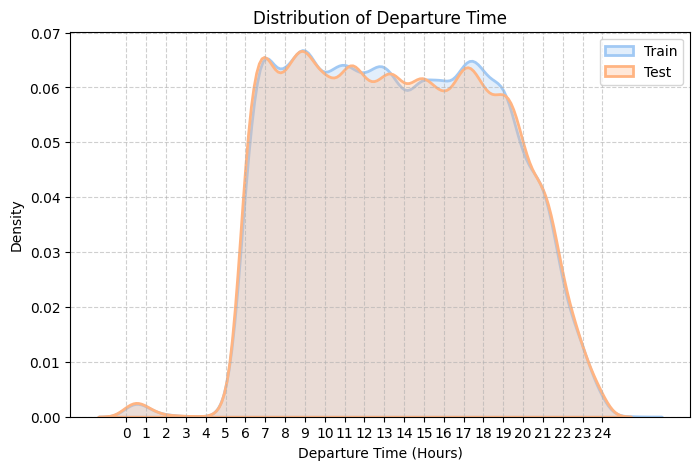

In [9]:
# Convert DepTime to decimal hours
train_df["DepTime_hours"] = train_df["DepTime"] // 100 + (train_df["DepTime"] % 100) / 60
test_df["DepTime_hours"] = test_df["DepTime"] // 100 + (test_df["DepTime"] % 100) / 60

# Plot DepTime distribution
plt.figure(figsize=(8, 5))
sns.kdeplot(train_df["DepTime_hours"], label="Train", linewidth=2, fill=True, alpha=0.3)
sns.kdeplot(test_df["DepTime_hours"], label="Test", linewidth=2, fill=True, alpha=0.3)
plt.xticks(range(0, 25, 1))
plt.xlabel("Departure Time (Hours)")
plt.ylabel("Density")
plt.title("Distribution of Departure Time")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


In [10]:
# KS Test for DepTime (after conversion)
ks_stat_dep, p_value_dep = ks_2samp(train_df["DepTime_hours"], test_df["DepTime_hours"])
print(f"KS test for Departure Time: statistic={ks_stat_dep:.4f}, p-value={p_value_dep:.4f}")

KS test for Departure Time: statistic=0.0063, p-value=0.0367


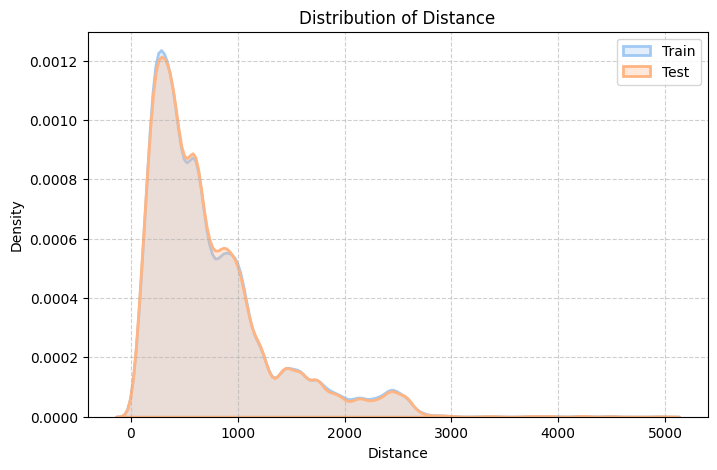

In [11]:
plt.figure(figsize=(8, 5))
sns.kdeplot(train_df["Distance"], label="Train", linewidth=2, fill=True, alpha=0.3)
sns.kdeplot(test_df["Distance"], label="Test", linewidth=2, fill=True, alpha=0.3)
plt.xlabel("Distance")
plt.ylabel("Density")
plt.title("Distribution of Distance")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [12]:
# KS Test for Distance
ks_stat_dist, p_value_dist = ks_2samp(train_df["Distance"], test_df["Distance"])
print(f"KS test for Distance: statistic={ks_stat_dist:.4f}, p-value={p_value_dist:.4f}")

KS test for Distance: statistic=0.0067, p-value=0.0233


📌 Conclusion:

Statistically, there are differences between the training and test sets for both variables.
Since the KS statistics are very small (0.0063 and 0.0067), the difference might not significantly impact the model.
To ensure good generalization, we could apply techniques such as reweighting, stratified sampling, or feature engineering to minimize this bias.

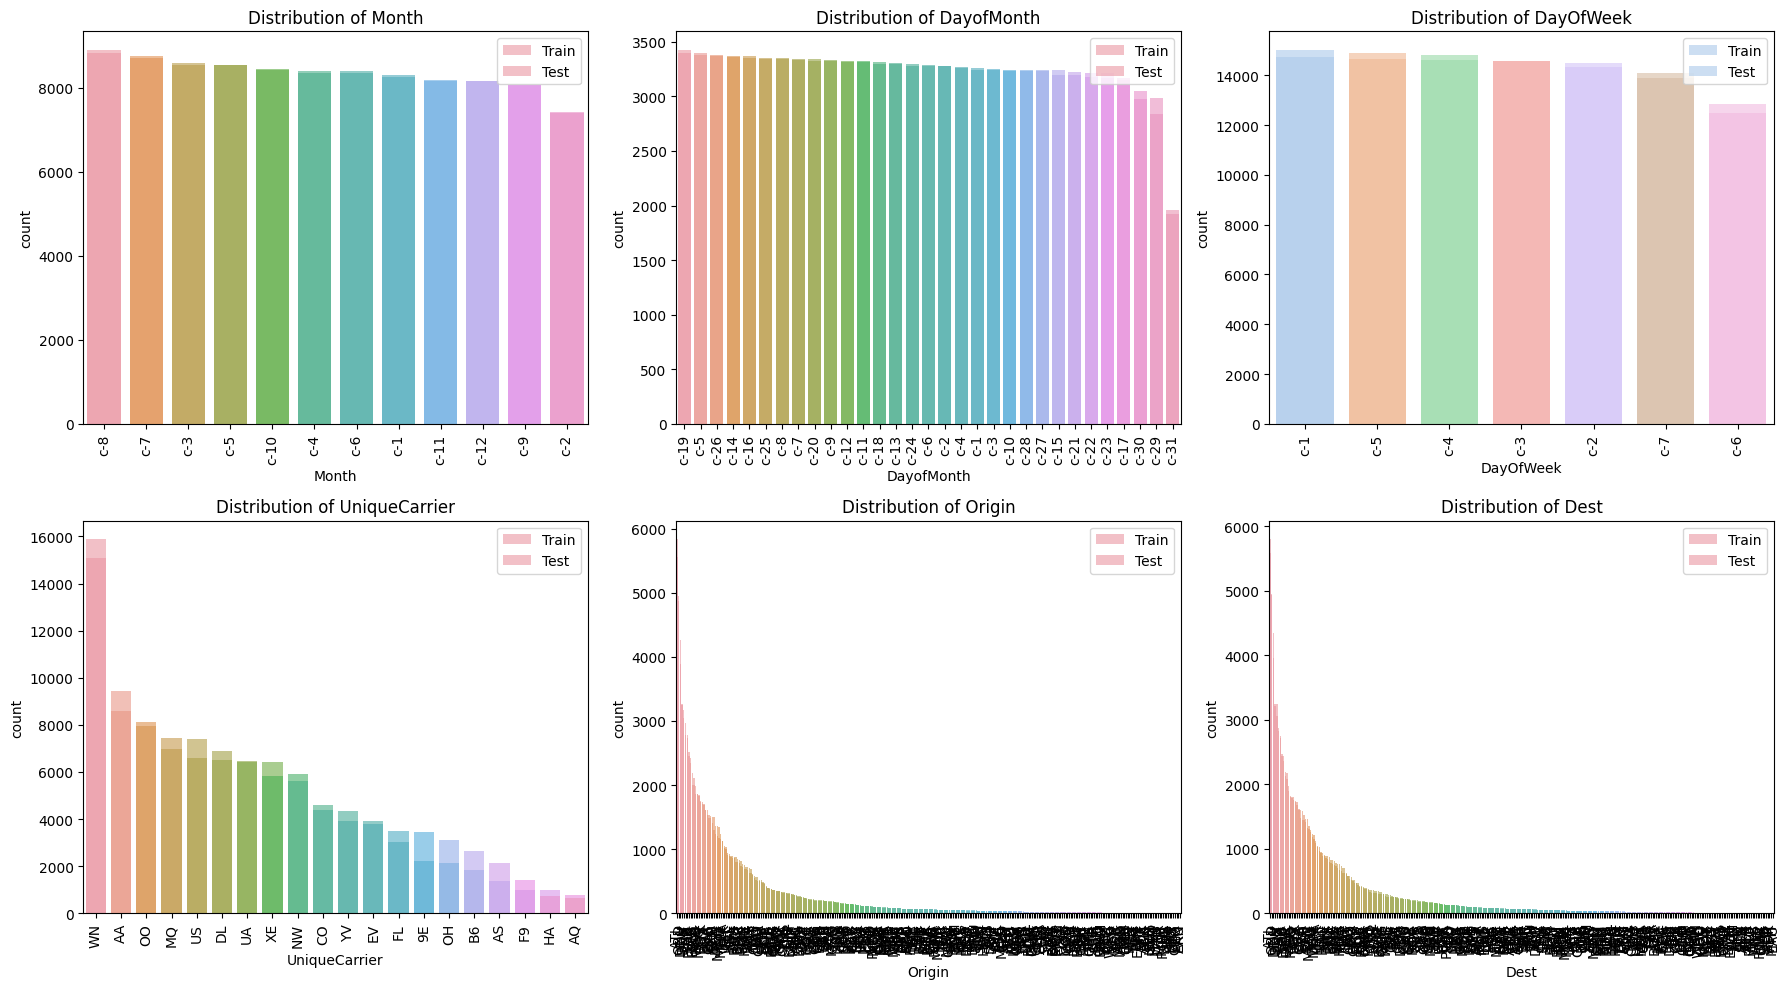

In [13]:
# Plot categorical feature distributions
cat_features = ["Month", "DayofMonth", "DayOfWeek", "UniqueCarrier", "Origin", "Dest"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.countplot(data=train_df, x=col, order=train_df[col].value_counts().index, ax=axes[i], alpha=0.6, label="Train")
    sns.countplot(data=test_df, x=col, order=test_df[col].value_counts().index, ax=axes[i], alpha=0.6, label="Test")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].legend()

plt.tight_layout()
plt.show()

In [14]:
def compute_js_divergence(train_col, test_col):
    """Computes Jensen-Shannon divergence between train and test distributions"""
    train_dist = train_col.value_counts(normalize=True).sort_index()
    test_dist = test_col.value_counts(normalize=True).sort_index()
    
    # Align indices to avoid mismatches
    all_categories = train_dist.index.union(test_dist.index)
    train_dist = train_dist.reindex(all_categories, fill_value=0)
    test_dist = test_dist.reindex(all_categories, fill_value=0)
    
    return jensenshannon(train_dist, test_dist)

In [15]:
cat_features = ["Month", "DayofMonth", "DayOfWeek", "UniqueCarrier", "Origin", "Dest"]

# Compute JS divergence for each categorical feature
js_results = {col: compute_js_divergence(train_df[col], test_df[col]) for col in cat_features}

# Print results
for col, js_div in js_results.items():
    print(f"JS Divergence for {col}: {js_div:.4f}")

JS Divergence for Month: 0.0037
JS Divergence for DayofMonth: 0.0112
JS Divergence for DayOfWeek: 0.0065
JS Divergence for UniqueCarrier: 0.1602
JS Divergence for Origin: 0.0584
JS Divergence for Dest: 0.0621


📌 Interpretation of the results:

- Month (0.0037), DayofMonth (0.0112), DayOfWeek (0.0065) → The distributions are almost identical between train and test sets. No concerns here.
- Origin (0.0584) and Dest (0.0621) → Small differences, but not critical.
- UniqueCarrier (0.1602) → Significant difference, meaning some airlines are more represented in either the train or test set.  

📌 Conclusion:

- The biggest discrepancy is in UniqueCarrier, which may introduce bias if this feature has a strong impact on flight delays.
- Other features show minor differences, so overall, the train and test sets are well-aligned.
- If needed, we could consider reweighting, resampling, or feature transformation to reduce the imbalance.

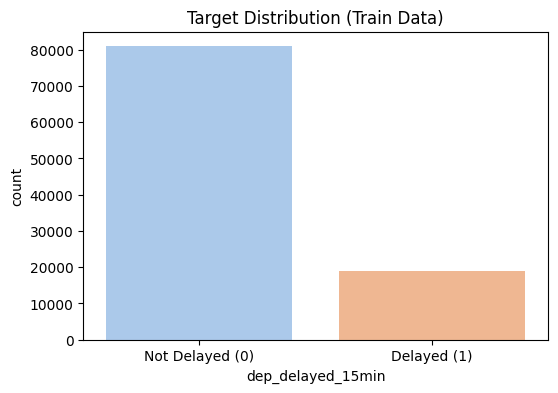

In [16]:
# Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=train_df["dep_delayed_15min"], palette="pastel")
plt.title("Target Distribution (Train Data)")
plt.xticks([0, 1], ["Not Delayed (0)", "Delayed (1)"])
plt.show()

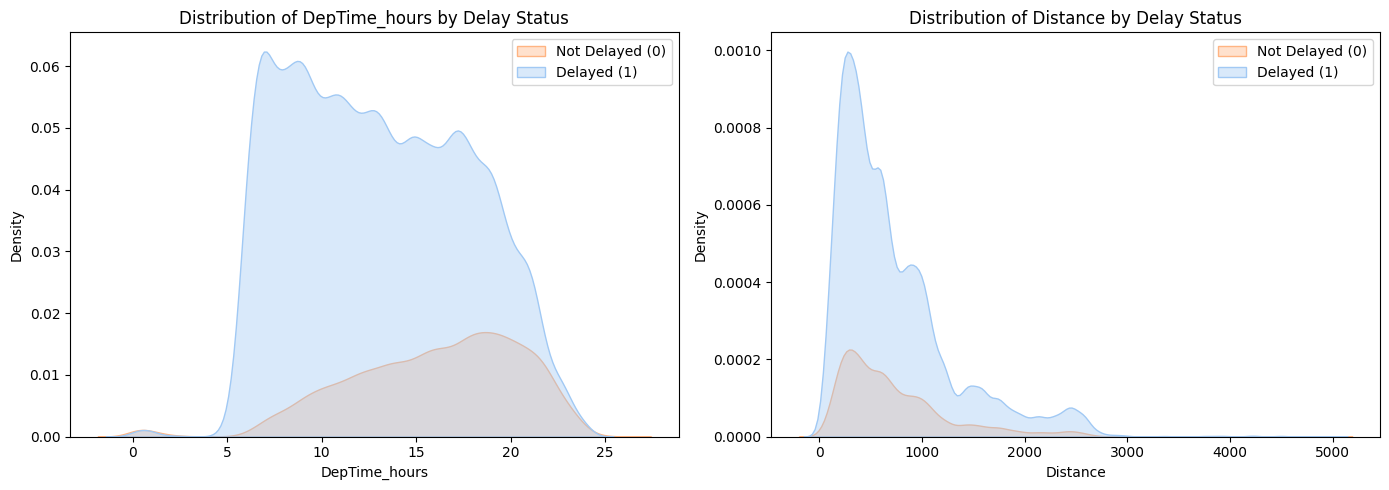

In [17]:
# Set pastel color palette
sns.set_palette("pastel")

# Numerical features comparison
num_features = ["DepTime_hours", "Distance"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(num_features):
    sns.kdeplot(data=train_df, x=col, hue="dep_delayed_15min", fill=True, ax=axes[i], alpha=0.4)
    axes[i].set_title(f"Distribution of {col} by Delay Status")
    axes[i].legend(["Not Delayed (0)", "Delayed (1)"])

plt.tight_layout()
plt.show()

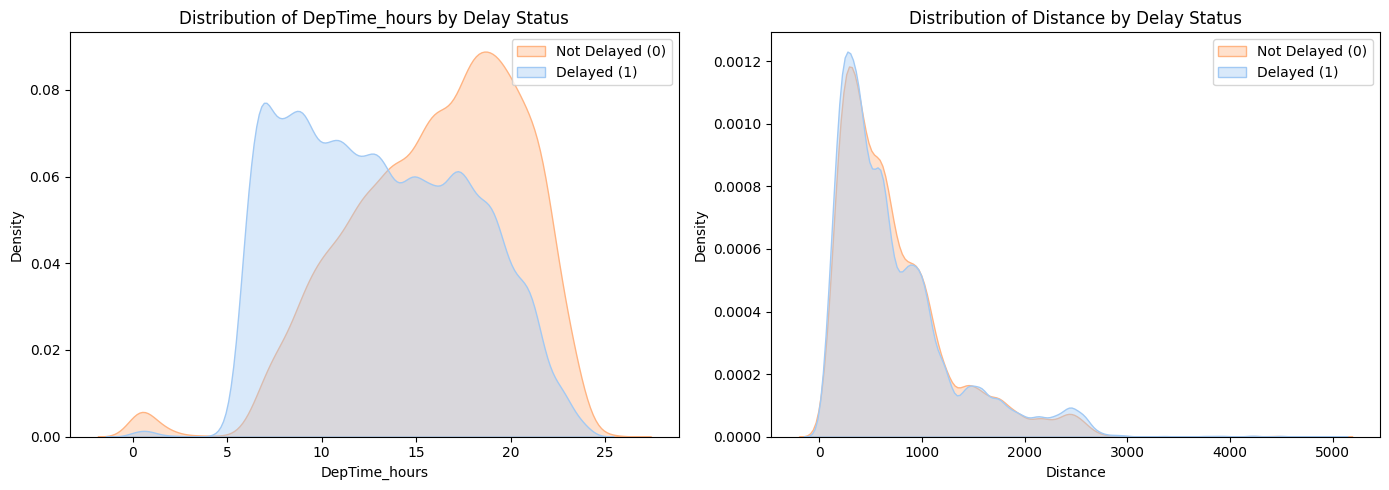

In [18]:
# Set pastel color palette
sns.set_palette("pastel")

# Numerical features comparison (Corrected)
num_features = ["DepTime_hours", "Distance"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(num_features):
    sns.kdeplot(data=train_df, x=col, hue="dep_delayed_15min", fill=True, ax=axes[i], alpha=0.4, common_norm=False)
    axes[i].set_title(f"Distribution of {col} by Delay Status")
    axes[i].legend(["Not Delayed (0)", "Delayed (1)"])

plt.tight_layout()
plt.show()


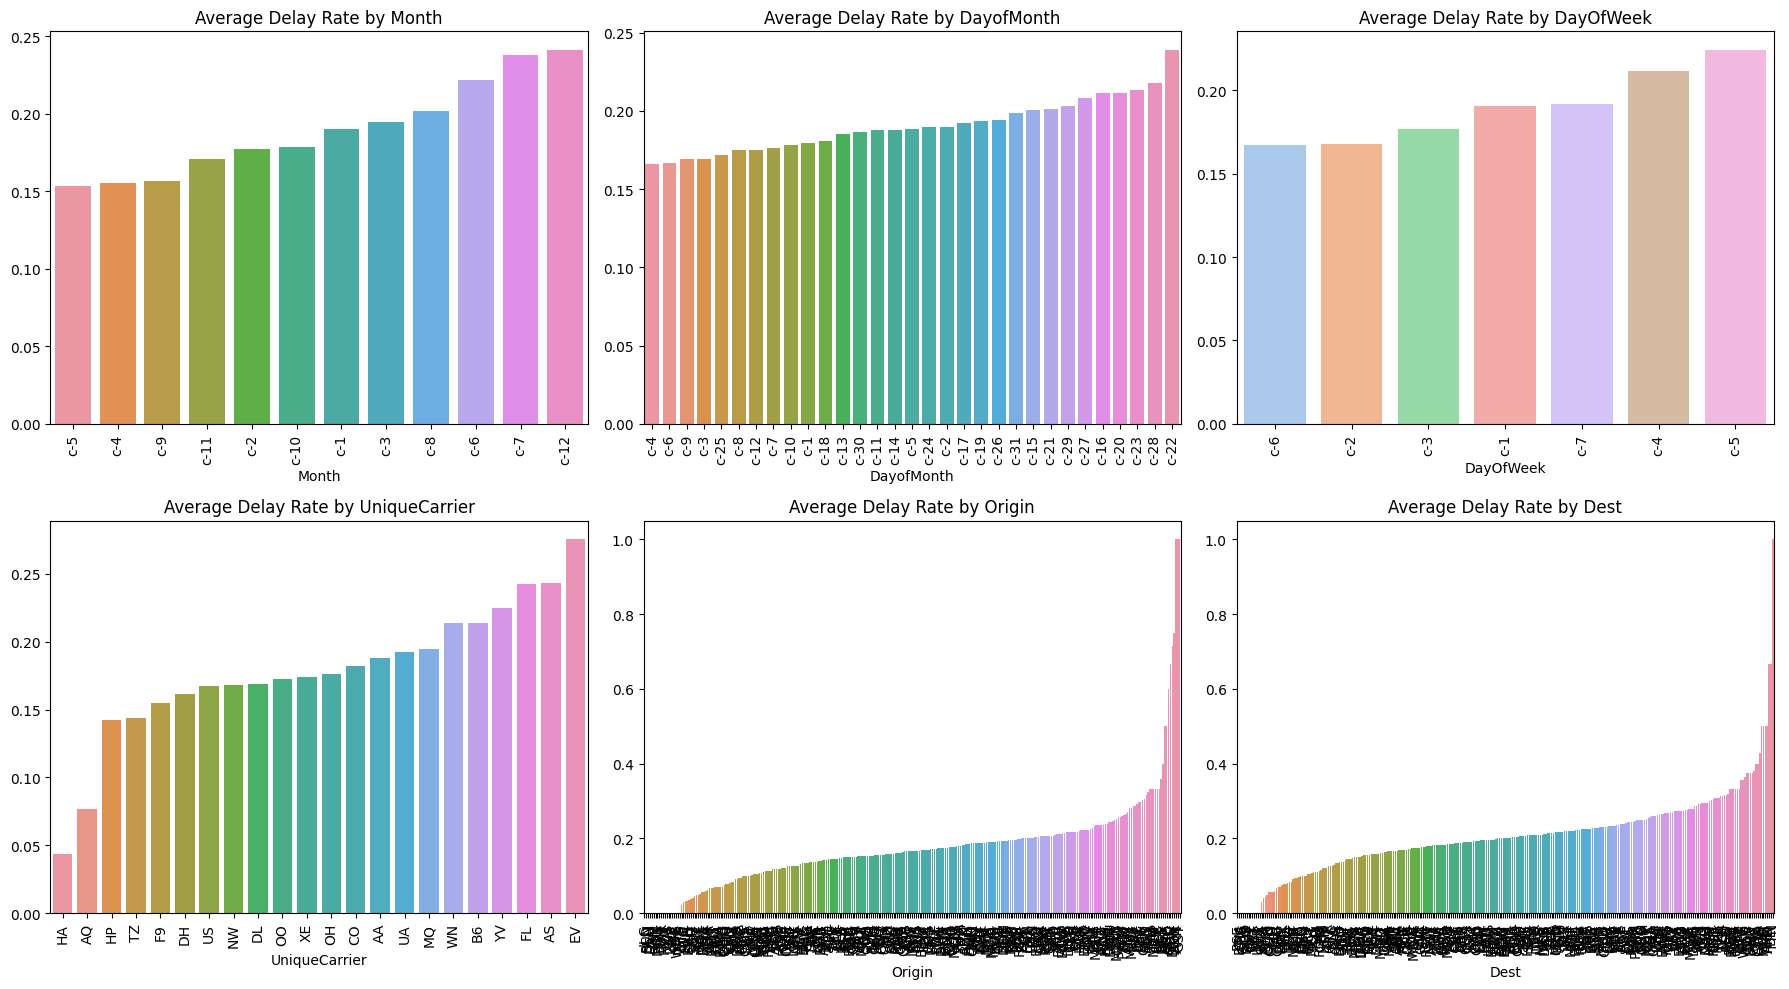

In [19]:
# Create a temporary column for visualization
train_df["delay_temp"] = train_df["dep_delayed_15min"].map({"N": 0, "Y": 1})

# Categorical features comparison
cat_features = ["Month", "DayofMonth", "DayOfWeek", "UniqueCarrier", "Origin", "Dest"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    delay_rate = train_df.groupby(col)["delay_temp"].mean().sort_values()
    
    # Convert index to string to avoid issues with numeric indices
    delay_rate.index = delay_rate.index.astype(str)

    sns.barplot(x=delay_rate.index, y=delay_rate.values, ax=axes[i])
    axes[i].set_title(f"Average Delay Rate by {col}")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

# Drop temporary column
train_df.drop(columns=["delay_temp"], inplace=True)


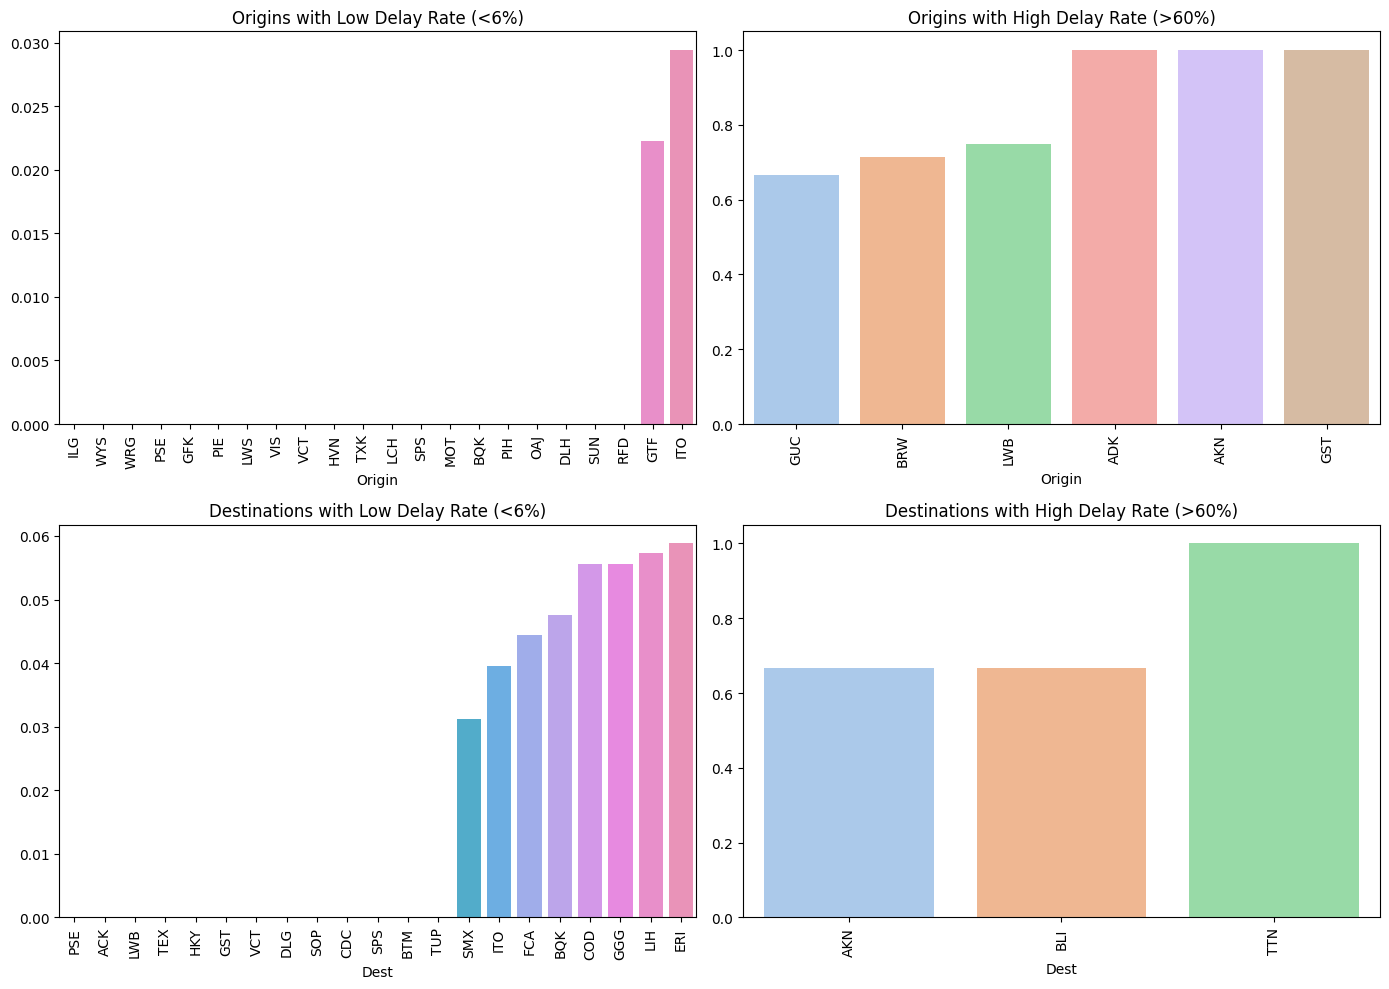

In [20]:
# Create a temporary column for visualization
train_df["delay_temp"] = train_df["dep_delayed_15min"].map({"N": 0, "Y": 1})

# Compute average delay rate for Origin and Dest
origin_delay = train_df.groupby("Origin")["delay_temp"].mean().sort_values()
dest_delay = train_df.groupby("Dest")["delay_temp"].mean().sort_values()

# Filter airports with extreme delay rates and sort them
low_delay_origin = origin_delay[origin_delay < 0.03].sort_values()
high_delay_origin = origin_delay[origin_delay > 0.6].sort_values()

low_delay_dest = dest_delay[dest_delay < 0.06].sort_values()
high_delay_dest = dest_delay[dest_delay > 0.6].sort_values()

# Plot the filtered results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(x=low_delay_origin.index, y=low_delay_origin.values, ax=axes[0, 0])
axes[0, 0].set_title("Origins with Low Delay Rate (<6%)")
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=90)

sns.barplot(x=high_delay_origin.index, y=high_delay_origin.values, ax=axes[0, 1])
axes[0, 1].set_title("Origins with High Delay Rate (>60%)")
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=90)

sns.barplot(x=low_delay_dest.index, y=low_delay_dest.values, ax=axes[1, 0])
axes[1, 0].set_title("Destinations with Low Delay Rate (<6%)")
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=90)

sns.barplot(x=high_delay_dest.index, y=high_delay_dest.values, ax=axes[1, 1])
axes[1, 1].set_title("Destinations with High Delay Rate (>60%)")
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

# Drop temporary column
train_df.drop(columns=["delay_temp"], inplace=True)


In [21]:
def check_category_differences(train_df, test_df, categorical_features):
    """
    Compare the unique categories in categorical features between training and test sets.
    
    Args:
        train_df (pd.DataFrame): Training dataset.
        test_df (pd.DataFrame): Test dataset.
        categorical_features (list): List of categorical columns to compare.

    Returns:
        None. Prints the categories exclusive to train and test.
    """
    for col in categorical_features:
        train_categories = set(train_df[col].unique())
        test_categories = set(test_df[col].unique())

        missing_in_test = train_categories - test_categories
        missing_in_train = test_categories - train_categories

        print(f"Feature: {col}")
        print(f"  Categories in train but missing in test: {missing_in_test}")
        print(f"  Categories in test but missing in train: {missing_in_train}")
        print("-" * 60)

# Run the category comparison
check_category_differences(train_df, test_df, CFG.cat_features)

Feature: Month
  Categories in train but missing in test: set()
  Categories in test but missing in train: set()
------------------------------------------------------------
Feature: DayofMonth
  Categories in train but missing in test: set()
  Categories in test but missing in train: set()
------------------------------------------------------------
Feature: DayOfWeek
  Categories in train but missing in test: set()
  Categories in test but missing in train: set()
------------------------------------------------------------
Feature: UniqueCarrier
  Categories in train but missing in test: {'TZ', 'DH', 'HP'}
  Categories in test but missing in train: {'9E'}
------------------------------------------------------------
Feature: Origin
  Categories in train but missing in test: {'HVN', 'HKY', 'CDC', 'ISO', 'VIS', 'VCT', 'PIE'}
  Categories in test but missing in train: {'TTN', 'EAU', 'CMX', 'SLE', 'ALO', 'SUX', 'EWN', 'ROW', 'RHI', 'HHH', 'BJI', 'PMD', 'YKM', 'PLN', 'SOP', 'INL', 'MTH', '

## Best Practices for Model Selection in Machine Learning

### 1. Understanding the Problem

#### **Task Type**
- The problem is **binary classification** → Models that handle structured tables are preferable.

#### **Feature Types**
- We have **categorical** and **numerical** features, meaning models should support mixed data.

#### **Dataset Size**
- The dataset is not massive → Models like **XGBoost and LightGBM** are efficient without requiring deep learning.

#### **Data Distribution**
- Some features strongly influence delays → Tree-based models handle these relationships well.

#### **Evaluation Metric**
- The competition metric is **ROC AUC** → Models that provide **well-calibrated probabilities** are ideal.

---

### 2. Recommended Models Based on Best Practices

#### **📌 Baseline Models (Initial Benchmarks)**

🔹 **Logistic Regression**
✔ Simple and interpretable.  
✔ Good starting point for model comparison.  
❌ May not capture complex relationships.  

🔹 **Random Forest**
✔ Works well with mixed data (categorical + numerical).  
✔ Fast to train, no need for normalization.  
❌ Can be slower than boosting models during inference.  

#### **📌 Advanced Models for Optimization**

🔹 **XGBoost (Extreme Gradient Boosting)**
✔ One of the best for structured datasets.  
✔ Handles **imbalanced data** and **categorical features** well.  
✔ Frequently wins Kaggle competitions.  
❌ Requires careful hyperparameter tuning.

🔹 **LightGBM (Light Gradient Boosting Machine)**  
✔ Similar to XGBoost but **faster and memory-efficient**.  
✔ Better for large datasets.  
❌ More sensitive to outliers without proper tuning.

🔹 **CatBoost (Categorical Boosting)**  
✔ Designed for **categorical features**, reducing the need for encoding.  
✔ Performs well on **small datasets**.  
❌ Slower training compared to LightGBM.

#### **📌 Other Less Recommended Options**

🔹 **Neural Networks (MLP)**  
❌ Deep Learning is not ideal for tabular data.  
❌ Tree-based models usually outperform neural networks for structured problems.

🔹 **SVM (Support Vector Machine)**  
❌ Inefficient for large datasets, harder to interpret.

---

### 3. Recommended Model Selection Process

✅ **Step 1:** Start with a **baseline** using `Logistic Regression` or `Random Forest`.  
✅ **Step 2:** Test **XGBoost, LightGBM, and CatBoost**, comparing their `ROC AUC` scores.  
✅ **Step 3:** Tune hyperparameters on the best-performing model.  
✅ **Step 4:** Assess overfitting and generalization using cross-validation.

---
#### **Feature Alignment for One-Hot Encoding (OHE)**

When applying One-Hot Encoding (OHE), categorical features must have consistent categories across training and test datasets. However, some categories exist in the training set but are missing in the test set, and vice versa. For instance, features like `Origin`, `Dest`, and `UniqueCarrier` contain discrepancies in category presence between datasets. This misalignment causes the model to expect encoded columns that may be absent in the test set, leading to errors during inference. To ensure compatibility, missing categories from the training set must be added with a default value (`0`), and any extra categories introduced in the test set should be ignored.

---

### 4. References and Documentation

🔗 [Scikit-learn: Choosing the right estimator](https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html)  
🔗 [XGBoost Docs](https://xgboost.readthedocs.io/en/stable/)  
🔗 [LightGBM Docs](https://lightgbm.readthedocs.io/en/latest/)  
🔗 [CatBoost Docs](https://catboost.ai/en/docs/)  
🔗 [Kaggle Discussions on Best ML Models](https://www.kaggle.com/discussions/)  

---

### Conclusion
✔ We will first test a baseline model like `Logistic Regression`. [See here](https://www.kaggle.com/code/luiscrmartins/flight-delay-prediction-using-logistic-regression)    
✔ We will first test a baseline model like `Random Forest`.  [See here](https://www.kaggle.com/code/luiscrmartins/flight-delay-prediction-using-random-forest)    
✔ Then, we will evaluate `XGBoost` (this notebook).  
✔ Then, we will evaluate `LightGBM`.  
✔ Then, we will evaluate `CatBoost`.  


🔹 **From Chat GPT**



# XGBoost (Extreme Gradient Boosting)  Model

## Preprocess Functions

In [22]:
def preprocess_ohe(train_df, test_df, target_column, cat_features, train_size, test_valid_rel, random_state):
    """
    Preprocess training and test data using One-Hot Encoding (OHE).
    - Concatenates train and test data before applying transformations to ensure consistency.
    - Splits the train set into training, validation, and independent test subsets.

    Args:
        train_df (pd.DataFrame): The training dataset.
        test_df (pd.DataFrame): The test dataset.
        target_column (str): The target column name.
        cat_features (list): List of categorical features.
        train_size (float): Proportion of data for training.
        test_valid_rel (float): Test size relative to the validation set.
        random_state (int): Random seed for reproducibility.

    Returns:
        - X_train, X_valid, X_train_test, X_test: Processed feature sets.
        - y_train, y_valid, y_train_test: Corresponding labels.

    """

    # Convert target column to binary labels
    y = train_df[target_column].map({"N": 0, "Y": 1})

    # Add identifier column to separate later
    train_df["dataset_type"] = "train"
    test_df["dataset_type"] = "test"

    # Drop target column from train data before concatenation
    train_df_features = train_df.drop(columns=[target_column])
    
    # Concatenate train and test to ensure consistent feature transformations
    combined_df = pd.concat([train_df_features, test_df], axis=0, ignore_index=True)

    # Define One-Hot Encoder for categorical features
    preprocessor = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features)
    ], remainder="passthrough")

    # Apply transformation
    X_combined_transformed = preprocessor.fit_transform(combined_df.drop(columns=["dataset_type"]))

    # Extract feature names
    ohe_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(cat_features)
    remainder_feature_names = combined_df.drop(columns=cat_features + ["dataset_type"]).columns.tolist()
    final_feature_names = list(ohe_feature_names) + remainder_feature_names

    # Convert transformed data back to DataFrame
    X_combined = pd.DataFrame(X_combined_transformed, columns=final_feature_names)

    # Split train and test based on the identifier
    X_train_full = X_combined[combined_df["dataset_type"] == "train"].reset_index(drop=True)
    X_test = X_combined[combined_df["dataset_type"] == "test"].reset_index(drop=True)

    # Train-validation-test split from training data
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_train_full, y, train_size=train_size, stratify=y, random_state=random_state
    )
    X_valid, X_train_test, y_valid, y_train_test = train_test_split(
        X_temp, y_temp, test_size=test_valid_rel, stratify=y_temp, random_state=random_state
    )

    return X_train, X_valid, X_train_test, X_test, y_train, y_valid, y_train_test



def preprocess_le(train_df, cat_features, target, train_size=0.7, test_valid_rel=0.5, random_state=42):
    """
    Preprocessing function using Label Encoding (LE).
    
    Args:
        train_df (pd.DataFrame): The input training dataset.
        cat_features (list): List of categorical features.
        target (str): Target column name.
        train_size (float): Proportion of data for training.
        test_valid_rel (float): Split ratio for validation and test.
        random_state (int): Random seed for reproducibility.
    
    Returns:
        X_train, X_valid, X_test, y_train, y_valid, y_test
    """
    # Convert target to binary
    y = train_df[target].map({"N": 0, "Y": 1})

    # Label Encode categorical features
    X = train_df.drop(columns=[target]).copy()
    for col in cat_features:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

    # Split into train, validation, and test sets
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=train_size, stratify=y, random_state=random_state)
    X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=test_valid_rel, stratify=y_temp, random_state=random_state)

    return X_train, X_valid, X_test, y_train, y_valid, y_test


def preprocess_le_test(test_df, cat_features, fitted_encoders):
    """
    Apply Label Encoding (LE) preprocessing to the test dataset using the trained label encoders.
    
    Args:
        test_df (pd.DataFrame): The test dataset.
        cat_features (list): List of categorical features.
        fitted_encoders (dict): A dictionary of fitted LabelEncoders for each categorical feature.
    
    Returns:
        X_test (pd.DataFrame): Transformed test data as DataFrame.
    """
    X_test = test_df.copy()
    
    # Apply the saved encoders to categorical features
    for col in cat_features:
        if col in fitted_encoders:
            X_test[col] = fitted_encoders[col].transform(X_test[col])
    
    return X_test

## OneHotEncoder Preprocess 

In [23]:
print(train_df.columns)

Index(['Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'UniqueCarrier', 'Origin', 'Dest', 'Distance', 'dep_delayed_15min', 'DepTime_hours'], dtype='object')


In [24]:
# One-Hot Encoding:
X_train, X_valid, X_train_test, X_test, y_train, y_valid, y_train_test = preprocess_ohe(
    train_df = train_df, 
    test_df = test_df,
    target_column = CFG.target, 
    cat_features = CFG.cat_features, 
    train_size = CFG.train_size, 
    test_valid_rel = CFG.test_valid_rel, 
    random_state = CFG.random_state
)

In [25]:
xgb_model_ohe = XGBClassifier(**CFG.xgb_params)
xgb_model_ohe.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [26]:
y_pred_proba = xgb_model_ohe.predict_proba(X_valid)[:, 1]
roc_auc = roc_auc_score(y_valid, y_pred_proba)
print(f"ROC AUC: {roc_auc:.4f}")

ROC AUC: 0.7497


In [27]:
y_pred_test_proba = xgb_model_ohe.predict_proba(X_train_test)[:, 1]
roc_auc_test = roc_auc_score(y_train_test, y_pred_test_proba)
print(f"ROC AUC: {roc_auc_test:.4f}")

ROC AUC: 0.7540


In [28]:
y_pred_test_proba

array([0.5632051 , 0.21283938, 0.08281844, ..., 0.24147011, 0.15215981,
       0.16595913], dtype=float32)

In [29]:
print(CFG.xgb_params)

{'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 9, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42}


- Simulations  
  {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8} OneHotEncoder debug false --> ROC AUC: 0.7375  
  {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 9, 'subsample': 0.8, 'colsample_bytree': 0.8} OneHotEncoder debug false --> ROC AUC: 0.7370  
  {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8} LabelEncoder  debug false --> ROC AUC: 0.7335  
  {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 9, 'subsample': 0.8, 'colsample_bytree': 0.8} OneHotEncoder debug false --> ROC AUC: 0.7502
  

# **Feature Encoding and Hyperparameter Tuning Analysis**

## **Overview**
This study explores different encoding techniques and hyperparameter settings for **XGBoost** in predicting flight delays. We tested **One-Hot Encoding (OHE) vs. Label Encoding (LE)** while varying the model's parameters to assess their impact on **ROC AUC performance**.

---

## **Experiments & Results**
| #  | Parameters Used | Encoding Type | ROC AUC |
|----|----------------|---------------|---------|
| **1**  | `{n_estimators: 100, learning_rate: 0.1, max_depth: 6, subsample: 0.8, colsample_bytree: 0.8}`  | **One-Hot Encoding**  | **0.7375** |
| **2**  | `{n_estimators: 200, learning_rate: 0.1, max_depth: 9, subsample: 0.8, colsample_bytree: 0.8}`  | **One-Hot Encoding**  | **0.7370** |
| **3**  | `{n_estimators: 100, learning_rate: 0.1, max_depth: 6, subsample: 0.8, colsample_bytree: 0.8}`  | **Label Encoding**    | **0.7335** |
| **4**  | `{n_estimators: 200, learning_rate: 0.1, max_depth: 9, subsample: 0.8, colsample_bytree: 0.8}`  | **One-Hot Encoding**  | **0.7502** |  
| **5**  | `{n_estimators: 200, learning_rate: 0.1, max_depth: 9, subsample: 0.8, colsample_bytree: 0.8}`  | **One-Hot Encoding**  | **0.7540** |  

---

## **Analysis & Conclusion**
- The best **ROC AUC score (0.7540)** was obtained with **One-Hot Encoding** and `n_estimators: 200, learning_rate: 0.1, max_depth: 9, subsample: 0.8, colsample_bytree: 0.8`.
- Increasing `n_estimators` and `max_depth` in **Experiment 2** did **not** improve performance, suggesting that more complex trees do not necessarily lead to better results.
- **Label Encoding** in **Experiment 3** performed worse (**0.7335**), likely because the model misinterpreted categorical values as numerical magnitudes.

### **Best Choice** ✅  
The best performing setup is **Experiment 5**, using:
- **One-Hot Encoding**
- `{n_estimators: 200, learning_rate: 0.1, max_depth: 9, subsample: 0.8, colsample_bytree: 0.8}`

# Predicting using OHE

In [30]:
# Generate predictions
y_test_proba = xgb_model_ohe.predict_proba(X_test)[:, 1]

# Creating the submission file

In [31]:
# Create the submission DataFrame
submission = pd.DataFrame({"id": test_df.index, "dep_delayed_15min": y_test_proba})

In [32]:
# Save as CSV
submission.to_csv(CFG.submission_file, index=False)

In [33]:
print(submission)

          id  dep_delayed_15min
0          0           0.027230
1          1           0.041309
2          2           0.040518
3          3           0.228797
4          4           0.221015
...      ...                ...
99995  99995           0.054543
99996  99996           0.257452
99997  99997           0.215425
99998  99998           0.088535
99999  99999           0.117028

[100000 rows x 2 columns]


In [34]:
submission.describe()

,id,dep_delayed_15min
count,100000.000000,100000.000000
mean,49999.500000,0.192607
std,28867.657797,0.150609
min,0.000000,0.001450
25%,24999.750000,0.086407
50%,49999.500000,0.159693
75%,74999.250000,0.257643
max,99999.000000,0.978499


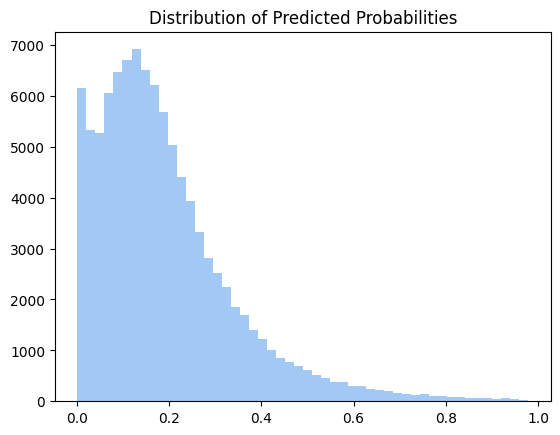

In [35]:
import matplotlib.pyplot as plt
plt.hist(y_test_proba, bins=50)
plt.title("Distribution of Predicted Probabilities")
plt.show()

In [36]:
train_df["dep_delayed_15min"].value_counts(normalize=True)


dep_delayed_15min
N    0.80956
Y    0.19044
Name: proportion, dtype: float64